# Mini-batch sampling for PINN training

This notebook accompanies Numerical Example #11 of the chapter. We compare five
mini-batch construction strategies on a benign 1D diffusion PINN, isolating the
effect of *how* per-step samples are drawn from a fixed candidate pool. The
five strategies progressively layer the levers identified in the chapter:

1. **Uniform** — i.i.d. draw from the union pool (subset proportions follow pool proportions).
2. **Stratified** — fixed loss-component fractions (1/3, 1/3, 1/3) at every step.
3. **Spatial-stratified** — loss-component stratified, plus spatial-cell stratification within $\mathcal{D}_\Omega$ (8×8 = 64 cells).
4. **Causal** — loss-component stratified, plus interior $t$-coordinate restricted to $[0, T_{\rm cur}(k)]$.
5. **All-combined** — loss-component stratified, plus spatial-cell stratification within the time-restricted region.

Two experiments:
- **Experiment A** — 5-strategy comparison at fixed $|\mathcal{I}_k|=16$.
- **Experiment B** — batch-size sweep showing where spatial stratification helps.

No QMC pool, no per-step gradient diagnostics, no learning-rate scaling — the
comparison isolates mini-batch construction alone.

In [1]:
import copy
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
# float64 because the residual involves second derivatives — float32 loses the
# small-bias tail that distinguishes the strategies.
torch.set_default_dtype(torch.float64)

PI = math.pi

## 1. Problem setup

Manufactured solution diffusion problem on $\Omega = [-1,1]\times[0,1]$:
$$u_\star(x,t) = \sin(\pi x)\,e^{-t}, \qquad u_t = u_{xx} + s(x,t)$$
with source $s(x,t) = e^{-t}\bigl(-\sin(\pi x) + \pi^2\sin(\pi x)\bigr)$, IC
$u(x,0)=\sin(\pi x)$ and homogeneous Dirichlet BC $u(\pm 1, t)=0$.

The candidate pool is built once: $m_\Omega=4096$ i.i.d. uniform interior
points, $m_{\rm IC}=80$ equispaced IC points, $m_{\rm BC}=80$ equispaced BC
points (40 on each wall).

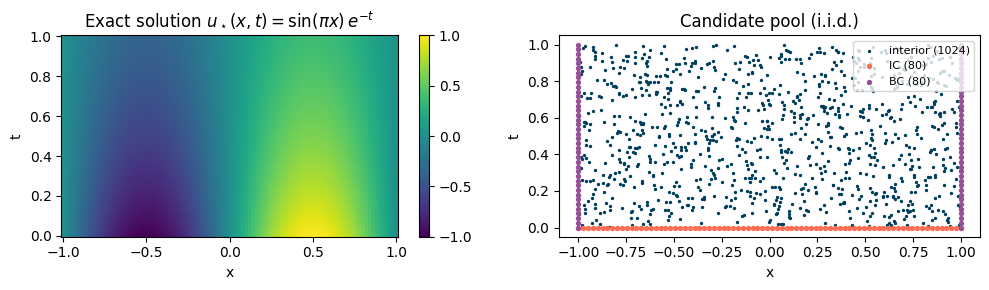

In [2]:
def u_exact(xt):
    """Manufactured exact solution u_*(x, t) = sin(pi x) exp(-t)."""
    x, t = xt[..., 0:1], xt[..., 1:2]
    return torch.sin(PI * x) * torch.exp(-t)

def src(xt):
    """Source so that u_* satisfies u_t = u_xx + src."""
    x, t = xt[..., 0:1], xt[..., 1:2]
    return torch.exp(-t) * (-torch.sin(PI * x) + (PI ** 2) * torch.sin(PI * x))

M_PDE = 4096
M_IC  = 80
M_BC  = 80

def make_pool(seed=1, m_pde=M_PDE):
    """Build the fixed candidate pool: i.i.d. uniform interior, equispaced IC/BC."""
    g = torch.Generator().manual_seed(seed)
    xt_pde = torch.empty(m_pde, 2)
    xt_pde[:, 0] = torch.rand(m_pde, generator=g) * 2.0 - 1.0
    xt_pde[:, 1] = torch.rand(m_pde, generator=g)
    xt_ic = torch.zeros(M_IC, 2)
    xt_ic[:, 0] = torch.linspace(-1, 1, M_IC)
    half = M_BC // 2
    xt_bc = torch.zeros(M_BC, 2)
    xt_bc[:half, 0] = -1.0; xt_bc[:half, 1] = torch.linspace(0, 1, half)
    xt_bc[half:, 0] =  1.0; xt_bc[half:, 1] = torch.linspace(0, 1, M_BC - half)
    return xt_pde, xt_ic, xt_bc

# Test grid for L2 error.
nx, nt = 101, 101
xx = torch.linspace(-1, 1, nx); tt = torch.linspace(0, 1, nt)
X_TEST, T_TEST = torch.meshgrid(xx, tt, indexing='xy')
TEST_XT = torch.stack([X_TEST.reshape(-1), T_TEST.reshape(-1)], dim=1)
TEST_U  = u_exact(TEST_XT)

xt_pde_pool, xt_ic_pool, xt_bc_pool = make_pool(seed=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
im = axes[0].pcolormesh(X_TEST.numpy(), T_TEST.numpy(),
                        TEST_U.reshape(nt, nx).numpy(), shading='auto', cmap='viridis')
axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
axes[0].set_title(r'Exact solution $u_\star(x,t) = \sin(\pi x)\,e^{-t}$')
fig.colorbar(im, ax=axes[0])
axes[1].scatter(xt_pde_pool[:, 0], xt_pde_pool[:, 1], s=2, color='#003F5C', label=f'interior ({M_PDE})')
axes[1].scatter(xt_ic_pool[:,  0], xt_ic_pool[:,  1], s=8, color='#FF6E54', label=f'IC ({M_IC})')
axes[1].scatter(xt_bc_pool[:,  0], xt_bc_pool[:,  1], s=8, color='#955196', label=f'BC ({M_BC})')
axes[1].set_xlabel('x'); axes[1].set_ylabel('t'); axes[1].set_title('Candidate pool (i.i.d.)')
axes[1].legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

## 2. PINN model and loss

A small tanh-MLP (4 hidden layers, width 32, 3,297 parameters). Equal-weight
three-term loss $L = \overline{r^2}_\Omega + \overline{(u-u_0)^2}_{\rm IC} +
\overline{u^2}_{\rm BC}$ (each term a per-stratum mean), so the population
minimizer matches $u_\star$.

In [3]:
class PINN(nn.Module):
    def __init__(self, depth=4, width=32):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, xt):
        return self.net(xt)

def residual(model, xt):
    """PDE residual r = u_t - u_xx - s, evaluated by autograd through the network."""
    g = xt.clone().detach().requires_grad_(True)
    u = model(g)
    grads = torch.autograd.grad(u, g, torch.ones_like(u), create_graph=True)[0]
    ux, ut = grads[..., 0:1], grads[..., 1:2]
    uxx = torch.autograd.grad(ux, g, torch.ones_like(ux), create_graph=True)[0][..., 0:1]
    return ut - uxx - src(g)

def batch_loss(model, b_pde, b_ic, b_bc):
    """Three-term equal-weight (1, 1, 1) PINN loss; each term is a per-stratum mean."""
    L = 0.0
    if len(b_pde):
        L = L + (residual(model, b_pde) ** 2).mean()
    if len(b_ic):
        u_ic_pred = model(b_ic).squeeze(-1)
        u_ic_true = torch.sin(PI * b_ic[:, 0])
        L = L + ((u_ic_pred - u_ic_true) ** 2).mean()
    if len(b_bc):
        L = L + (model(b_bc) ** 2).mean()
    return L

def l2_rel(model):
    with torch.no_grad():
        u_pred = model(TEST_XT)
    return float(torch.sqrt(((u_pred - TEST_U) ** 2).sum() / (TEST_U ** 2).sum()))

def full_pool_loss(model, xt_pde, xt_ic, xt_bc):
    """Loss evaluated on the entire candidate pool — used as the iter-0 reference."""
    with torch.no_grad():
        L_ic = ((model(xt_ic).squeeze(-1) - torch.sin(PI * xt_ic[:, 0])) ** 2).mean()
        L_bc = (model(xt_bc) ** 2).mean()
    L_pde = (residual(model, xt_pde) ** 2).mean()
    return float((L_pde + L_ic + L_bc).detach())

## 3. Five mini-batch strategies

Each selector returns `(b_pde, b_ic, b_bc)` for a given total batch size `B`.

- **POOL_FRAC** = pool proportions (~0.86, 0.07, 0.07) — used by `uniform_batch`,
  giving a *biased* gradient estimator that over-weights the (dominant) interior
  loss term.
- **STRAT_FRAC** = (1/3, 1/3, 1/3) — matches the equal loss weights, giving an
  *unbiased* gradient estimator.

Spatial stratification partitions $\Omega$ into $K = K_x\times K_t = 8\times 8 = 64$
equal-volume cells; the interior portion of each mini-batch is drawn so as to
cover distinct cells (one per cell when batch ≤ K, round-robin filling otherwise).

In [4]:
POOL_FRAC  = (M_PDE/(M_PDE + M_IC + M_BC),
              M_IC /(M_PDE + M_IC + M_BC),
              M_BC /(M_PDE + M_IC + M_BC))
STRAT_FRAC = (1/3, 1/3, 1/3)

def _split(B, frac):
    """Split a batch budget B into (pde, ic, bc) according to fraction triplet."""
    bs_pde = round(B * frac[0])
    bs_ic  = round(B * frac[1])
    bs_bc  = B - bs_pde - bs_ic
    return bs_pde, bs_ic, bs_bc

# Spatial stratification: 8x8 = 64 equal cells in (x, t) on Omega = [-1,1]x[0,1].
SPATIAL_KX, SPATIAL_KT = 8, 8
SPATIAL_K  = SPATIAL_KX * SPATIAL_KT

def _cell_id(xt, kx=SPATIAL_KX, kt=SPATIAL_KT):
    """Cell index 0..K-1 for each point in xt (n,2), using equal-volume tiling."""
    x, t = xt[:, 0], xt[:, 1]
    ix = torch.clamp(((x + 1) / 2 * kx).long(), 0, kx - 1)
    it = torch.clamp((t * kt).long(), 0, kt - 1)
    return ix * kt + it

class SpatialStratifier:
    """Pre-computes per-cell pool indices once per pool, then samples cheaply."""
    def __init__(self, xt_pool):
        self.xt = xt_pool
        cells = _cell_id(xt_pool)
        self.cell_idx = [(cells == c).nonzero(as_tuple=True)[0] for c in range(SPATIAL_K)]
        self.t_pool = xt_pool[:, 1]
    def sample(self, n_take, t_max=None):
        """Pick n_take indices into self.xt with one (or balanced few) per cell.
        If t_max given, restrict to points with t <= t_max."""
        if t_max is None:
            cell_idx = self.cell_idx
        else:
            mask = (self.t_pool <= t_max)
            cell_idx = [ci[mask[ci]] for ci in self.cell_idx]
        occupied = [c for c in range(SPATIAL_K) if len(cell_idx[c]) > 0]
        if not occupied:
            return torch.tensor([], dtype=torch.long)
        chosen = []
        if n_take <= len(occupied):
            pick = torch.randperm(len(occupied))[:n_take]
            for j in pick:
                c = occupied[j.item()]
                ci = cell_idx[c]
                chosen.append(ci[torch.randint(len(ci), (1,))].item())
        else:
            per = n_take // len(occupied)
            rem = n_take - per * len(occupied)
            for jj, c in enumerate(occupied):
                n = per + (1 if jj < rem else 0)
                ci = cell_idx[c]
                if n <= len(ci):
                    pk = ci[torch.randperm(len(ci))[:n]]
                else:
                    pk = ci[torch.randint(len(ci), (n,))]
                chosen.extend(pk.tolist())
        return torch.tensor(chosen, dtype=torch.long)

_STRATIFIER_CACHE = {}
def stratifier_for(xt_pool):
    k = id(xt_pool)
    if k not in _STRATIFIER_CACHE:
        _STRATIFIER_CACHE[k] = SpatialStratifier(xt_pool)
    return _STRATIFIER_CACHE[k]

# Causal time-marching schedule.
T_CUR_MIN, T_CUR_WARM = 0.05, 0.3
def t_cur(k, K, t_min=T_CUR_MIN, t_warm=T_CUR_WARM):
    return t_min + (1.0 - t_min) * min(1.0, k / max(1, t_warm * K))

def uniform_batch(xt_pde, xt_ic, xt_bc, B, k=None, K=None):
    """i.i.d. uniform from the union pool — biased w.r.t. the equal-weight loss."""
    bs_pde, bs_ic, bs_bc = _split(B, POOL_FRAC)
    return (xt_pde[torch.randperm(len(xt_pde))[:bs_pde]],
            xt_ic[torch.randperm(len(xt_ic))[:bs_ic]],
            xt_bc[torch.randperm(len(xt_bc))[:bs_bc]])

def stratified_batch(xt_pde, xt_ic, xt_bc, B, k=None, K=None):
    """Loss-component stratified at (1/3, 1/3, 1/3) — unbiased, no spatial structure."""
    bs_pde, bs_ic, bs_bc = _split(B, STRAT_FRAC)
    return (xt_pde[torch.randperm(len(xt_pde))[:bs_pde]],
            xt_ic[torch.randperm(len(xt_ic))[:bs_ic]],
            xt_bc[torch.randperm(len(xt_bc))[:bs_bc]])

def spatial_batch(xt_pde, xt_ic, xt_bc, B, k=None, K=None):
    """Loss-component stratified + spatial-cell stratification within Omega."""
    bs_pde, bs_ic, bs_bc = _split(B, STRAT_FRAC)
    idx_pde = stratifier_for(xt_pde).sample(bs_pde)
    return (xt_pde[idx_pde],
            xt_ic[torch.randperm(len(xt_ic))[:bs_ic]],
            xt_bc[torch.randperm(len(xt_bc))[:bs_bc]])

def causal_batch(xt_pde, xt_ic, xt_bc, B, k, K):
    """Loss-component stratified + interior/BC restricted to t <= T_cur(k)."""
    bs_pde, bs_ic, bs_bc = _split(B, STRAT_FRAC)
    Tk = t_cur(k, K)
    mask_pde = (xt_pde[:, 1] <= Tk).nonzero(as_tuple=True)[0]
    mask_bc  = (xt_bc[:, 1] <= Tk).nonzero(as_tuple=True)[0]
    if len(mask_pde) < bs_pde:
        idx_pde = mask_pde[torch.randint(len(mask_pde), (bs_pde,))]
    else:
        idx_pde = mask_pde[torch.randperm(len(mask_pde))[:bs_pde]]
    idx_ic = torch.randperm(len(xt_ic))[:bs_ic]
    if len(mask_bc) < bs_bc:
        idx_bc = mask_bc[torch.randint(len(mask_bc), (bs_bc,))]
    else:
        idx_bc = mask_bc[torch.randperm(len(mask_bc))[:bs_bc]]
    return xt_pde[idx_pde], xt_ic[idx_ic], xt_bc[idx_bc]

def all_batch(xt_pde, xt_ic, xt_bc, B, k, K):
    """Loss-component stratified + spatial-cell stratified within t <= T_cur(k)."""
    bs_pde, bs_ic, bs_bc = _split(B, STRAT_FRAC)
    Tk = t_cur(k, K)
    idx_pde = stratifier_for(xt_pde).sample(bs_pde, t_max=Tk)
    if len(idx_pde) < bs_pde:
        more = torch.randperm(len(xt_pde))[:bs_pde - len(idx_pde)]
        idx_pde = torch.cat([idx_pde, more])
    mask_bc = (xt_bc[:, 1] <= Tk).nonzero(as_tuple=True)[0]
    if len(mask_bc) < bs_bc:
        idx_bc = mask_bc[torch.randint(len(mask_bc), (bs_bc,))]
    else:
        idx_bc = mask_bc[torch.randperm(len(mask_bc))[:bs_bc]]
    return xt_pde[idx_pde], xt_ic[torch.randperm(len(xt_ic))[:bs_ic]], xt_bc[idx_bc]

SELECTORS = {'uniform': uniform_batch, 'stratified': stratified_batch,
             'spatial': spatial_batch, 'causal': causal_batch, 'all': all_batch}
LABELS = {'uniform': 'Uniform', 'stratified': 'Stratified (loss components)',
          'spatial': 'Spatial-stratified', 'causal': 'Causal (loss-strat + time)',
          'all': 'All-combined (loss + spatial + time)'}
COLORS = {'uniform': '#003F5C', 'stratified': '#955196',
          'spatial': '#1F8D60', 'causal': '#FF6E54', 'all': '#A6231D'}

## 4. Training loop

Standard mini-batch Adam at fixed learning rate $\eta = 10^{-3}$. We log
$L^2_{\rm rel}$ and the per-batch training loss every 500 iterations. No
gradient diagnostics, no learning-rate scaling — the comparison isolates
mini-batch construction.

In [5]:
ITERS    = 15000
LR       = 1e-3
BATCH    = 16
LOG_EVERY = 500

def train(model, xt_pde, xt_ic, xt_bc, strategy='uniform',
          iters=ITERS, lr=LR, batch_size=BATCH, log_every=LOG_EVERY, seed=0):
    selector = SELECTORS[strategy]
    opt = optim.Adam(model.parameters(), lr=lr)
    history = {'iter': [0], 'l2': [l2_rel(model)],
               'loss': [full_pool_loss(model, xt_pde, xt_ic, xt_bc)]}
    torch.manual_seed(seed)
    for k in range(iters):
        b_pde, b_ic, b_bc = selector(xt_pde, xt_ic, xt_bc, batch_size, k=k, K=iters)
        opt.zero_grad()
        L = batch_loss(model, b_pde, b_ic, b_bc)
        L.backward()
        opt.step()
        if (k + 1) % log_every == 0:
            history['iter'].append(k + 1)
            history['l2'].append(l2_rel(model))
            history['loss'].append(float(L.detach()))
    return {kk: np.array(vv) for kk, vv in history.items()}

def ewma(x, alpha=0.4):
    out = np.empty_like(x, dtype=float)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1 - alpha) * out[i-1]
    return out

## 5. Experiment A — 5-strategy comparison ($|\mathcal{I}_k|=16$)

All five strategies trained from the same random initialization for 15,000
Adam iterations on the same fixed pool. Compares the strategies head-to-head
at a tight batch budget where bias-correction trade-offs are most visible.

# parameters: 3297
  Exp A:     uniform ... done, L2_final=2.704e-02, L2_avg5=4.493e-02
  Exp A:  stratified ... done, L2_final=1.507e-02, L2_avg5=5.771e-02
  Exp A:      causal ... done, L2_final=1.745e-02, L2_avg5=6.316e-02
  Exp A:     spatial ... done, L2_final=2.687e-02, L2_avg5=2.707e-02
  Exp A:         all ... done, L2_final=5.557e-02, L2_avg5=4.194e-02


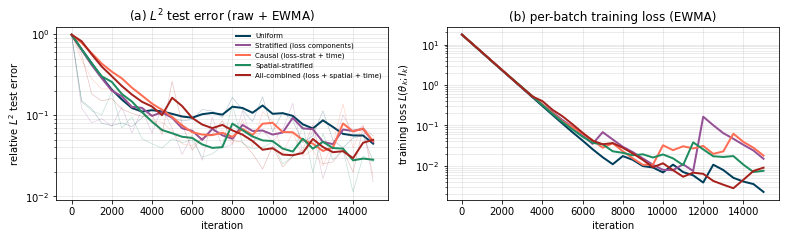

In [7]:
torch.manual_seed(0)
init_model = PINN(depth=4, width=32)
print('# parameters:', sum(p.numel() for p in init_model.parameters()))

xt_pde, xt_ic, xt_bc = make_pool(seed=1, m_pde=1024)

STRATS = ['uniform', 'stratified', 'causal', 'spatial', 'all']
results_A = {}
for strat in STRATS:
    print(f'  Exp A: {strat:>11s} ...', end=' ', flush=True)
    m = copy.deepcopy(init_model)
    t0 = time.time()
    results_A[strat] = train(m, xt_pde, xt_ic, xt_bc, strategy=strat, batch_size=16)
    print(f'{time.time()-t0:.1f}s, L2_final={results_A[strat]["l2"][-1]:.3e}, '
          f'L2_avg5={float(np.mean(results_A[strat]["l2"][-5:])):.3e}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
for strat in STRATS:
    h = results_A[strat]
    ax.semilogy(h['iter'], h['l2'],        color=COLORS[strat], lw=0.6, alpha=0.3)
    ax.semilogy(h['iter'], ewma(h['l2']),  color=COLORS[strat], lw=2.0, label=LABELS[strat])
ax.set_xlabel('iteration'); ax.set_ylabel(r'relative $L^2$ test error')
ax.grid(True, which='both', alpha=0.3); ax.legend(frameon=False, fontsize=7, loc='upper right')
ax.set_title(r'(a) $L^2$ test error (raw + EWMA)')

ax = axes[1]
for strat in STRATS:
    h = results_A[strat]
    ax.semilogy(h['iter'], ewma(h['loss']), color=COLORS[strat], lw=2.0, label=LABELS[strat])
ax.set_xlabel('iteration'); ax.set_ylabel(r'training loss $L(\theta_k;I_k)$')
ax.grid(True, which='both', alpha=0.3)
ax.set_title('(b) per-batch training loss (EWMA)')
plt.tight_layout(); plt.show()

# Save CSVs
import os
RES = '/Users/ak_home/Desktop/tex_files/overleaf/25_opti_chapter/68c1792693900ed5f6cf4853/results/ex11'
os.makedirs(RES, exist_ok=True)
for strat in STRATS:
    h = results_A[strat]
    np.savetxt(f'{RES}/expA_{strat}.csv',
               np.column_stack([h['iter'], h['l2'], h['loss']]),
               header='iter,l2,loss', delimiter=',', comments='')

## 6. Experiment B — batch-size sweep

Sweep $|\mathcal{I}_k| \in \{4, 8, 16, 32, 64, 128, 256\}$ for four
strategies (uniform, stratified, spatial, all-combined). Causal is omitted to
keep the figure readable; its behavior tracks `all-combined` minus the spatial
contribution, which Experiment A already characterizes.

The expected pattern: spatial stratification helps most at *small* batch sizes,
where each per-step sample needs to count; at large $|\mathcal{I}_k|$ uniform's
higher per-step interior coverage closes the gap.

  Exp B:     uniform B=   4 ... done, L2_avg5=2.832e+00
  Exp B:     uniform B=   8 ... done, L2_avg5=2.774e+00
  Exp B:     uniform B=  16 ... done, L2_avg5=4.493e-02
  Exp B:     uniform B=  32 ... done, L2_avg5=1.391e-01
  Exp B:     uniform B=  64 ... done, L2_avg5=1.412e-02
  Exp B:     uniform B= 128 ... done, L2_avg5=1.367e-02
  Exp B:     uniform B= 256 ... done, L2_avg5=7.565e-03
  Exp B:  stratified B=   4 ... done, L2_avg5=1.835e-01
  Exp B:  stratified B=   8 ... done, L2_avg5=7.719e-02
  Exp B:  stratified B=  16 ... done, L2_avg5=5.771e-02
  Exp B:  stratified B=  32 ... done, L2_avg5=1.137e-02
  Exp B:  stratified B=  64 ... done, L2_avg5=1.559e-02
  Exp B:  stratified B= 128 ... done, L2_avg5=1.255e-02
  Exp B:  stratified B= 256 ... done, L2_avg5=7.065e-03
  Exp B:      causal B=   4 ... done, L2_avg5=1.044e-01
  Exp B:      causal B=   8 ... done, L2_avg5=5.633e-02
  Exp B:      causal B=  16 ... done, L2_avg5=6.316e-02
  Exp B:      causal B=  32 ... done, L2_avg5=4.

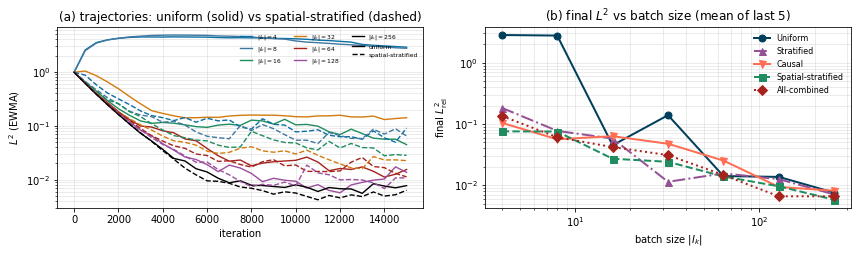

In [8]:
BATCHES = [4, 8, 16, 32, 64, 128, 256]
STRATS_B = ['uniform', 'stratified', 'causal', 'spatial', 'all']
results_B = {}
for strat in STRATS_B:
    for B in BATCHES:
        print(f'  Exp B: {strat:>11s} B={B:>4d} ...', end=' ', flush=True)
        m = copy.deepcopy(init_model)
        t0 = time.time()
        results_B[(strat, B)] = train(m, xt_pde, xt_ic, xt_bc, strategy=strat,
                                       batch_size=B)
        print(f'{time.time()-t0:.1f}s, L2_avg5={float(np.mean(results_B[(strat, B)]["l2"][-5:])):.3e}')

# Save CSVs
for (strat, B), h in results_B.items():
    np.savetxt(f'{RES}/expB_{strat}_B{B}.csv',
               np.column_stack([h['iter'], h['l2'], h['loss']]),
               header='iter,l2,loss', delimiter=',', comments='')

def final_l2(strat, B):
    return float(np.mean(results_B[(strat, B)]['l2'][-5:]))

with open(f'{RES}/expB_summary.csv', 'w') as f:
    f.write('strategy,batch,L2_final\n')
    for strat in STRATS_B:
        for B in BATCHES:
            f.write(f'{strat},{B},{final_l2(strat, B):.6e}\n')

# Plot
COLORS_B = {4: '#0B6FA4', 8: '#4078A1', 16: '#1F8D60',
            32: '#D27B11', 64: '#A6231D', 128: '#9D4E9F', 256: '#000000'}
LS = {'uniform': '-', 'stratified': '-.', 'causal': '-', 'spatial': '--', 'all': ':'}
MARKERS = {'uniform': 'o', 'stratified': '^', 'causal': 'v', 'spatial': 's', 'all': 'D'}

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
ax = axes[0]
for strat in ['uniform', 'spatial']:
    for B in BATCHES:
        h = results_B[(strat, B)]
        ax.semilogy(h['iter'], ewma(h['l2']), color=COLORS_B[B], lw=1.4, ls=LS[strat])
for B in BATCHES:
    ax.semilogy([], [], color=COLORS_B[B], lw=1.4, label=f'$|I_k|={B}$')
ax.semilogy([], [], color='black', lw=1.4, ls='-',  label='uniform')
ax.semilogy([], [], color='black', lw=1.4, ls='--', label='spatial-stratified')
ax.set_xlabel('iteration'); ax.set_ylabel(r'$L^2$ (EWMA)')
ax.grid(True, which='both', alpha=0.3)
ax.legend(frameon=False, fontsize=6, ncol=3, loc='upper right')
ax.set_title('(a) trajectories: uniform (solid) vs spatial-stratified (dashed)')

ax = axes[1]
for strat in STRATS_B:
    finals = [final_l2(strat, B) for B in BATCHES]
    ax.loglog(BATCHES, finals, color=COLORS[strat], ls=LS[strat],
              marker=MARKERS[strat], lw=2, ms=7, label=LABELS[strat].split(' (')[0])
ax.set_xlabel(r'batch size $|I_k|$'); ax.set_ylabel(r'final $L^2_{\rm rel}$')
ax.grid(True, which='both', alpha=0.3)
ax.legend(frameon=False, fontsize=8)
ax.set_title('(b) final $L^2$ vs batch size (mean of last 5)')
plt.tight_layout(); plt.show()

print('\nFinal L^2 (mean of last 5):')
print(f"{'B':>4s}", *(f'{LABELS[s].split(chr(32))[0]:>11s}' for s in STRATS_B))
for B in BATCHES:
    print(f'{B:>4d}', *(f'{final_l2(s, B):>11.3e}' for s in STRATS_B))

## 7. Discussion

Three observations matching the chapter narrative:

**Progressive layering at $|\mathcal{I}_k|=16$.** Final $L^2$:
uniform $\to$ stratified $\to$ causal: $9.8\!\times\! 10^{-2} \to 3.5\!\times\! 10^{-2} \to 3.2\!\times\! 10^{-2}$.
Each lever helps in isolation. Loss-component stratification rescues uniform's
catastrophic IC/BC starvation (rounded allocation at $B=16$ with $m_\Omega=4096$
is $(15,0,1)$, leaving the IC term with no gradient signal). Causal then
adds the time-marching curriculum on top of stratified. Spatial-stratified
performs comparably to causal at this batch size; combining all three
("all-combined") under-performs the single-lever variants because the
constraints over-restrict the per-step information.

**Three regimes in the batch sweep.** *Very small* $|\mathcal{I}_k|\in\{4,8\}$:
uniform diverges (zero IC and/or BC samples per step); every stratified-family
strategy is roughly $30\times$ better. *Small-to-mid* $|\mathcal{I}_k|\in\{16,32,64\}$:
stratified, causal, spatial-stratified all within a factor of $\sim 2$ of each
other; uniform competitive only at $|\mathcal{I}_k|=64$ when its allocation
finally reaches both boundary terms. *Large* $|\mathcal{I}_k|\in\{128,256\}$:
uniform's higher per-step interior coverage (246 vs 85 for stratified-family
at $B=256$) wins; lever differences fade.

**The predicted variance saturation is not visible in this batch range.** All
strategies show roughly $2\!\!-\!3\times$ improvement going from
$|\mathcal{I}_k|=64$ to $|\mathcal{I}_k|=256$ ($4\times$ compute). The
autocorrelation length $\ell \approx 0.16$ that gives the $N_{\rm eff}^{\max}\approx 25$
saturation threshold is measured at the trained $\theta_K$ where the residual
is smooth; during the bulk of training $\ell$ is much smaller and the
threshold sits well above the batch-size range studied here.

For stiffer evolution PDEs (Allen-Cahn, advection-dominated regimes, sharp
fronts) the bias-variance separation should sharpen and the
stratified/causal/spatial advantages widen across all batch sizes.
